In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['png']
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcdefaults()

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

In [2]:
import hdfstream
import numpy as np

import pynbody

root_dir = hdfstream.open("https://dataweb.cosma.dur.ac.uk:8443/hdfstream", "/")
simulation = "FLAMINGO/L1_m10/L1_m10_DMO"
root_dir[simulation]

<Remote directory /FLAMINGO/L1_m10/L1_m10_DMO with 6 sub-directories, 7 files>

In [3]:
soap = pynbody.load(f"{simulation}/SOAP-HBT/halo_properties_0077.hdf5", remote_dir=root_dir)
soap

<SOAPSnap "FLAMINGO/L1_m10/L1_m10_DMO/SOAP-HBT/halo_properties_0077.hdf5" len=1627212>

In [4]:
soap.properties

{'a': np.float64(1.0),
 'h': np.float64(0.681),
 'omegaM0': np.float64(0.30461099999999997),
 'omegaL0': np.float64(0.693922),
 'omegaB0': np.float64(0.0486),
 'omegaC0': np.float64(0.256011),
 'omegaNu0': np.float64(0.0013890794316214667),
 'boxsize': Unit("3.09e+27 a cm"),
 'time': Unit("4.34e+17 s")}

In [5]:
len(soap.loadable_keys())

417

In [6]:
sorted({key for key in soap.loadable_keys() if 'TotalMass' in key})

['BoundSubhalo/TotalMass',
 'ExclusiveSphere/1000kpc/TotalMass',
 'ExclusiveSphere/100kpc/TotalMass',
 'ExclusiveSphere/10kpc/TotalMass',
 'ExclusiveSphere/3000kpc/TotalMass',
 'ExclusiveSphere/300kpc/TotalMass',
 'ExclusiveSphere/30kpc/TotalMass',
 'ExclusiveSphere/500kpc/TotalMass',
 'ExclusiveSphere/50kpc/TotalMass',
 'InclusiveSphere/1000kpc/TotalMass',
 'InclusiveSphere/100kpc/TotalMass',
 'InclusiveSphere/10kpc/TotalMass',
 'InclusiveSphere/3000kpc/TotalMass',
 'InclusiveSphere/300kpc/TotalMass',
 'InclusiveSphere/30kpc/TotalMass',
 'InclusiveSphere/500kpc/TotalMass',
 'InclusiveSphere/50kpc/TotalMass',
 'ProjectedAperture/100kpc/projx/TotalMass',
 'ProjectedAperture/100kpc/projy/TotalMass',
 'ProjectedAperture/100kpc/projz/TotalMass',
 'ProjectedAperture/10kpc/projx/TotalMass',
 'ProjectedAperture/10kpc/projy/TotalMass',
 'ProjectedAperture/10kpc/projz/TotalMass',
 'ProjectedAperture/30kpc/projx/TotalMass',
 'ProjectedAperture/30kpc/projy/TotalMass',
 'ProjectedAperture/30kpc/pr

In [7]:
m200c = soap['SO/200_crit/TotalMass']
i = np.argmax(m200c)

print(f"Most massive halo is row {i}, with M200c = {m200c.in_units('Msol')[i]:.3e} Msol")

Most massive halo is row 206947, with M200c = 2.340e+15 Msol


In [8]:
target_pos = soap['pos'][i]
target_index = soap['InputHalos/HaloCatalogueIndex'][i]
r200c = soap['SO/200_crit/SORadius'][i] * soap['SO/200_crit/SORadius'].units

print("Centre:", target_pos, soap['pos'].units)
print("HaloCatalogueIndex:", target_index)
print("R200c:", r200c.in_units("Mpc a"), "Mpc a")

Centre: [115.97934688 966.26593688 908.51006688] 3.09e+24 cm a
HaloCatalogueIndex: 1129761
R200c: 2.7890624986519925 Mpc a


In [9]:
neighbourhood = soap[pynbody.filt.Sphere("10 Mpc a", target_pos) & pynbody.filt.HighPass('SO/200_crit/TotalMass', '1e13 Msol')]
print(f"{len(neighbourhood)} haloes; M200c / Msol =", np.sort(neighbourhood['SO/200_crit/TotalMass'].in_units('Msol'))[::-1])

5 haloes; M200c / Msol = [2.3398284e+15 6.9279651e+13 1.6159919e+13 1.0399948e+13 1.0299948e+13]


In [10]:
region = pynbody.filt.Sphere("8 Mpc a", target_pos)
snap = pynbody.load(f"{simulation}/snapshots/flamingo_0077/flamingo_0077.hdf5",
                    remote_dir=root_dir, take_region=region)
snap

<SwiftSnap "FLAMINGO/L1_m10/L1_m10_DMO/snapshots/flamingo_0077/flamingo_0077.hdf5" len=341057>

In [11]:
halo = snap[snap['HaloCatalogueIndex'] == target_index]

print(f"Read {len(snap)} particles, of which {len(halo)} belong to the halo")
print("Number of bound DM particles according to SOAP:", soap['BoundSubhalo/NumberOfDarkMatterParticles'][i])

Read 341057 particles, of which 54809 belong to the halo
Number of bound DM particles according to SOAP: 54809


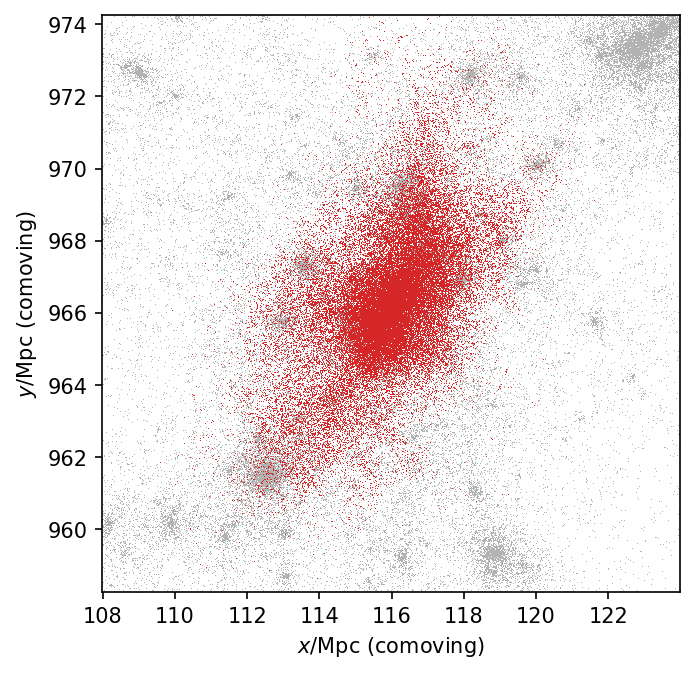

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(snap['x'].in_units('Mpc a'), snap['y'].in_units('Mpc a'), ',', color='0.7')
ax.plot(halo['x'].in_units('Mpc a'), halo['y'].in_units('Mpc a'), ',', color='C3')
plt.xlim(target_pos[0]-8, target_pos[0]+8)
plt.ylim(target_pos[1]-8, target_pos[1]+8)
ax.set_aspect('equal')
ax.set_xlabel(r"$x / \mathrm{Mpc}$ (comoving)")
ax.set_ylabel(r"$y / \mathrm{Mpc}$ (comoving)");

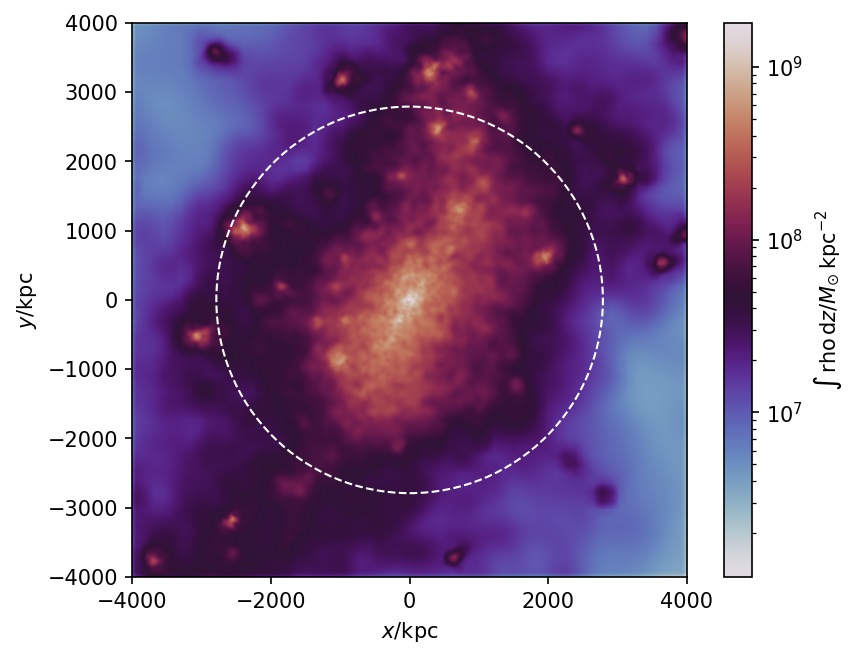

In [13]:
snap.translate(-target_pos)
snap.physical_units()

pynbody.plot.image(snap, width="8 Mpc", units="Msol kpc^-2", cmap="twilight", resolution=500)
r200c_kpc = float(r200c.in_units("kpc", **snap.conversion_context()))
plt.gca().add_patch(plt.Circle((0, 0), r200c_kpc, fill=False, color='w', ls='--'));

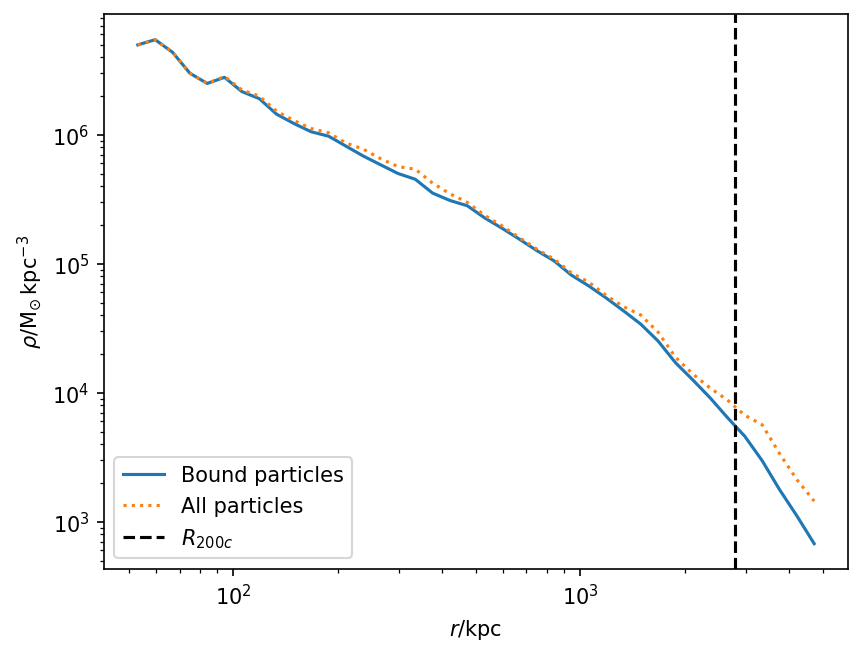

In [14]:
p = pynbody.analysis.Profile(halo, rmin="50 kpc", rmax="5 Mpc", nbins=40, type='log', ndim=3)
p_all = pynbody.analysis.Profile(snap, rmin="50 kpc", rmax="5 Mpc", nbins=40, type='log', ndim=3)

fig, ax = plt.subplots()
ax.loglog(p['rbins'].in_units('kpc'), p['density'].in_units('Msol kpc^-3'), label='Bound particles')
ax.loglog(p_all['rbins'].in_units('kpc'), p_all['density'].in_units('Msol kpc^-3'),":", label='All particles')
ax.axvline(r200c_kpc, color='k', ls='--', label='$R_{200c}$')
ax.set_xlabel(r"$r / \mathrm{kpc}$")
ax.set_ylabel(r"$\rho / \mathrm{M_{\odot}\,kpc^{-3}}$")
ax.legend();